In [1]:
!pip install kaggle

  Using cached bleach-6.3.0-py3-none-any.whl.metadata (31 kB)
  Using cached python_slugify-8.0.4-py2.py3-none-any.whl.metadata (8.5 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached webencodings-0.5.1-py2.py3-none-any.whl.metadata (2.1 kB)
  Using cached text_unidecode-1.3-py2.py3-none-any.whl.metadata (2.4 kB)
  Using cached charset_normalizer-3.4.4-cp313-cp313-win_amd64.whl.metadata (38 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
Using cached bleach-6.3.0-py3-none-any.whl (164 kB)
Using cached python_slugify-8.0.4-py2.py3-none-any.whl (10 kB)
Using cached text_unidecode-1.3-py2.py3-none-any.whl (78 kB)
Using cached requests-2.32.5-py3-none-any.whl (64 kB)
Using cached charset_normalizer-3.4.4-cp313-cp313-win_amd64.whl (107 kB)
Using cached idna-3.11-py3-none-any.whl (71 kB)
Using cached webencodings-0.5.1-py2.py3-


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os 
import json

kaggle_username = "rasulbekruzmetov"
kaggle_key = "KGAT_3af50e40f42c98fcd3141f5ac4df8509"

home_dir = os.path.expanduser("~")
kaggle_dir = os.path.join(home_dir, ".kaggle")

os.makedirs(kaggle_dir, exist_ok=True)

kaggle_file_path = os.path.join(kaggle_dir, "kaggle.json")

kaggle_data = {
    "username": kaggle_username, 
    "key": kaggle_key
}

with open(kaggle_file_path, "w") as f:
    json.dump(kaggle_data, f)

print("kaggle.json muvaffaqiyatli yaratildi")
print("Joylashuvi", kaggle_file_path)

kaggle.json muvaffaqiyatli yaratildi
Joylashuvi C:\Users\Rasulbek907\.kaggle\kaggle.json


In [ ]:
import os 
os.system("kaggle datasets download -d ronitf/heart-disease-uci")

1

In [12]:
import subprocess

result = subprocess.run(
    ["kaggle", "datasets", "download", "-d", "ineubytes/heart-disease-dataset"],
    capture_output=True,
    text=True
)

print("Return Code: ", result.returncode)
print("Output: ", result.stdout)
print("Error: ", result.stderr)

Return Code:  0
Output:  Dataset URL: https://www.kaggle.com/datasets/ineubytes/heart-disease-dataset
License(s): unknown


Error:  
  0%|          | 0.00/6.18k [00:00<?, ?B/s]
100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 6.18k/6.18k [00:00<00:00, 5.33MB/s]



In [14]:
import zipfile 
import pandas as pd 

zip_path = r"C:\Users\Rasulbek907\Desktop\Project_One\Notebooks\heart-disease-dataset.zip"

with zipfile.ZipFile(zip_path, "r")  as zip_ref:
    zip_ref.extractall(r"C:\Users\Rasulbek907\Desktop\Project_One\Notebooks\heart_data")

print("Dataset ochildi") 

csv_path = r"C:\Users\Rasulbek907\Desktop\Project_One\Notebooks\heart_data\heart.csv"
df = pd.read_csv(csv_path)

print(df.head())
print("Shape", df.shape)

Dataset ochildi
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
Shape (1025, 14)


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [16]:
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype=="object":
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].mean(), inplace=True)

In [17]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype=="object":
        if df[col].nunique()<=5:
            dummies = pd.get_dummies(df[col], prefix=col, dtype=int)
            df = pd.concat([df.drop(columns=col), dummies], axis=1)
        else:
            df[col] = encoder.fit_transform(df[col])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [19]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [20]:
from sklearn.preprocessing import MinMaxScaler

numerical_cols = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]

scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
print(df[numerical_cols].head())

        age  sex   cp  trestbps      chol  fbs  restecg   thalach  exang  \
0  0.479167  1.0  0.0  0.292453  0.196347  0.0      0.5  0.740458    0.0   
1  0.500000  1.0  0.0  0.433962  0.175799  1.0      0.0  0.641221    1.0   
2  0.854167  1.0  0.0  0.481132  0.109589  0.0      0.5  0.412214    1.0   
3  0.666667  1.0  0.0  0.509434  0.175799  0.0      0.5  0.687023    0.0   
4  0.687500  0.0  0.0  0.415094  0.383562  1.0      0.5  0.267176    0.0   

    oldpeak  slope    ca      thal  target  
0  0.161290    1.0  0.50  1.000000     0.0  
1  0.500000    0.0  0.00  1.000000     0.0  
2  0.419355    0.0  0.00  1.000000     0.0  
3  0.000000    1.0  0.25  1.000000     0.0  
4  0.306452    0.5  0.75  0.666667     0.0  


In [21]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.479167,1.0,0.0,0.292453,0.196347,0.0,0.5,0.740458,0.0,0.161290,1.0,0.50,1.000000,0.0
1,0.500000,1.0,0.0,0.433962,0.175799,1.0,0.0,0.641221,1.0,0.500000,0.0,0.00,1.000000,0.0
2,0.854167,1.0,0.0,0.481132,0.109589,0.0,0.5,0.412214,1.0,0.419355,0.0,0.00,1.000000,0.0
3,0.666667,1.0,0.0,0.509434,0.175799,0.0,0.5,0.687023,0.0,0.000000,1.0,0.25,1.000000,0.0
4,0.687500,0.0,0.0,0.415094,0.383562,1.0,0.5,0.267176,0.0,0.306452,0.5,0.75,0.666667,0.0


# UNS ML turlari
- Clustering 
- Anomaly Detection 
- Asosiation Rule Learning
- Density Estimation 
- Generative Models 
- Dimnesionality Reduction 

# Clusteringda mavjud algaritmlar 
- KMeans
- Herarchical Clustering 
- DBSCAN 
- Mean Shift 
- Guassian Mixture 
- Spectral Clustering

# Hierarchical Clustering Algaritmi 

# 2 xil turi mavjud 
- Agglomerative - har bir nuqta alohida guruh qilinadi va keyin birlashtiriladi 
- Divisive  - hamma nuqtalar bitta guruh keyin bo`linadi 

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   float64
 1   sex       1025 non-null   float64
 2   cp        1025 non-null   float64
 3   trestbps  1025 non-null   float64
 4   chol      1025 non-null   float64
 5   fbs       1025 non-null   float64
 6   restecg   1025 non-null   float64
 7   thalach   1025 non-null   float64
 8   exang     1025 non-null   float64
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   float64
 11  ca        1025 non-null   float64
 12  thal      1025 non-null   float64
 13  target    1025 non-null   float64
dtypes: float64(14)
memory usage: 112.2 KB


# K Means

K - Means Clustering Results
Labels [2 0 0 2 1 3 2 0 2 0]
Silhouette Score: 0.23027950905566302
Calinski Harabz Score: 218.3728305449872


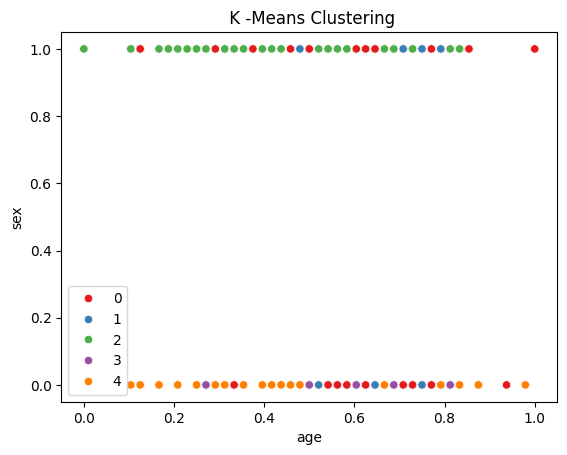

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.pyplot as plt 
import seaborn as sns 

features = df.drop(["target"], axis=1)

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(features)

sil_score = silhouette_score(features, kmeans_labels) 
ch_score = calinski_harabasz_score(features, kmeans_labels)

print("K - Means Clustering Results")
print("Labels", kmeans_labels[:10])
print("Silhouette Score:", sil_score)
print("Calinski Harabz Score:", ch_score)

sns.scatterplot(x = features.iloc[:,0], y=features.iloc[:,1], hue=kmeans_labels, palette="Set1")
plt.title(" K -Means Clustering")
plt.show()

# Hirarchical Clustering 

 Hierarchical Clustering Results
Labels [2 1 0 2 0 4 0 0 2 3]
Silhouette Score: 0.39814253750172063
Calinski Harabz Score: 856.5102886399035


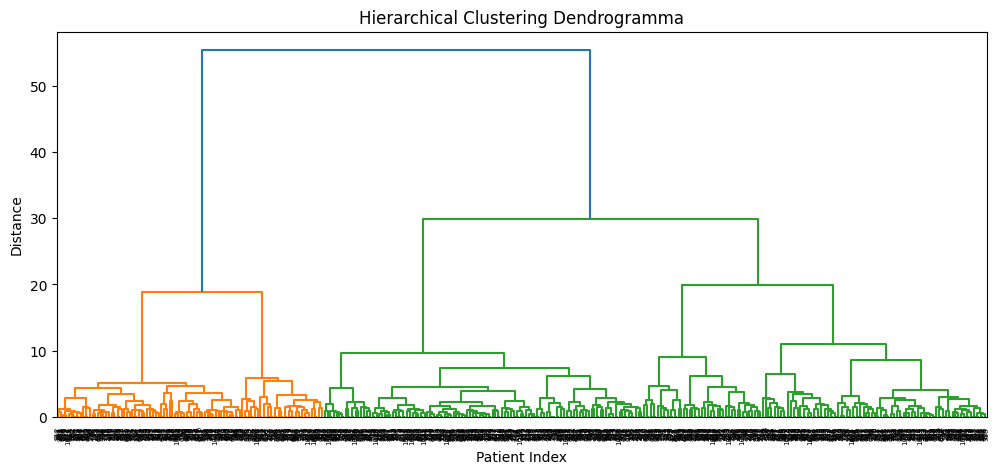

              age       sex        cp  trestbps      chol       fbs   restecg  \
cluster                                                                         
0        0.592322  0.717742  0.071237  0.388733  0.309398  0.012097  0.245968   
1        0.585242  0.732824  0.422392  0.422512  0.287445  1.000000  0.206107   
2        0.448390  1.000000  0.446970  0.324855  0.247230  0.000000  0.303977   
3        0.596383  0.956044  0.054945  0.363674  0.249084  0.208791  0.137363   
4        0.529351  0.000000  0.426929  0.317734  0.279529  0.000000  0.315271   

          thalach     exang   oldpeak     slope        ca      thal    target  
cluster                                                                        
0        0.467526  0.665323  0.334157  0.493952  0.288306  0.926075  0.120968  
1        0.611794  0.335878  0.169293  0.671756  0.259542  0.816794  0.541985  
2        0.698907  0.150568  0.097553  0.828125  0.132812  0.795455  0.630682  
3        0.436624  0.780220  0.2

In [31]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

features = df.drop("target", axis=1)


hier = AgglomerativeClustering(n_clusters=5, linkage="ward")
hier_labels = hier.fit_predict(features)

sil_score_h = silhouette_score(features, hier_labels)
ch_score_h = calinski_harabasz_score(features, hier_labels)

print(" Hierarchical Clustering Results")
print("Labels", hier_labels[:10])
print("Silhouette Score:", sil_score_h)
print("Calinski Harabz Score:", ch_score_h)

linked = linkage(features, method="ward")
plt.figure(figsize=(12, 5))
dendrogram(linked, labels=df.index.values, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogramma")
plt.xlabel("Patient Index")
plt.ylabel("Distance")
plt.show()

df["cluster"] = hier_labels
print(df.groupby("cluster").mean())

# Linkage bu - ikki klaster orasidagi masofani qanday hisoblashni bildiradi
turlari 
- Single - eng qisqa masofani topadi 
- Complete - eng uzoq masofani topadi
- Average  - ortacha madofani topadi
- Ward  - klasterlar ichidagi variansni minimal qilishga harakat qiladi (ko`proq shu usul tavsiya qilinadi)

# Saqlash 

In [32]:
import os 

output_dir = r"C:\Users\Rasulbek907\Desktop\Project_One\Data\Clustering"
os.makedirs(output_dir, exist_ok=True)

output_csv = os.path.join(output_dir, "heart_cluster_hierarchical.csv")

df.to_csv(output_csv, index=False)
print(f"Natija CSV faylga saqlandi:, ", {output_csv})

Natija CSV faylga saqlandi:,  {'C:\\Users\\Rasulbek907\\Desktop\\Project_One\\Data\\Clustering\\heart_cluster_hierarchical.csv'}
